In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import random
from mpl_toolkits.mplot3d import Axes3D 
from sklearn.neighbors import KernelDensity
import statistics 
import csv
import torch
import pandas as pd 

In [2]:
a0 = 3426.89
b0 = -3476.32
c0 = 0.10182
sigma = 40.296
mu = 24.3823
photons = np.linspace(2,200,1000)
f_photons = 1/3233*(a0*np.exp(-(photons-mu)**2 / (2*sigma**2)) + b0*np.exp(-c0*photons))

In [24]:
max(f_photons)

1.0000640325719201

Text(0, 0.5, 'Probability')

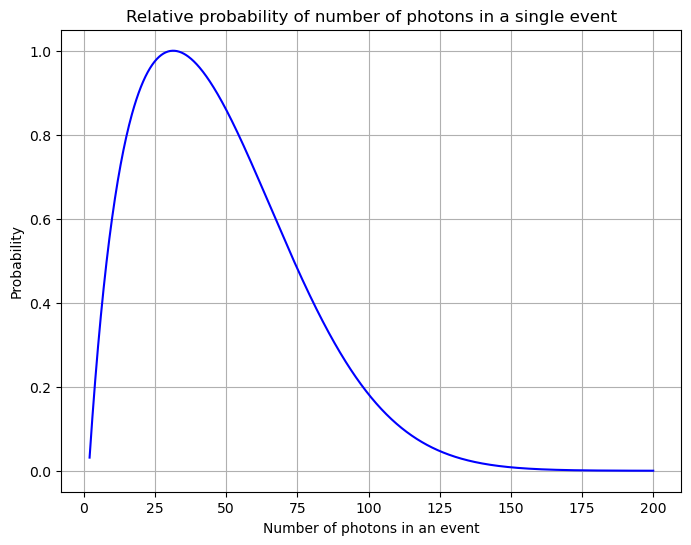

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))
# ax.gca().set_facecolor('gray') 
# fig.gcf().set_facecolor('gray')  # Change to any color you prefer
ax.plot(photons, f_photons, c="b")
ax.grid()
ax.set_title("Relative probability of number of photons in a single event")
ax.set_xlabel("Number of photons in an event")
ax.set_ylabel("Probability")
#plt.tight_layout()
#plt.subplots_adjust(top=0.9, bottom = 0.15, left = 0.15, right = 1.2)

In [91]:
## 2. Time Decay
a1 = 57782.4
t1 = 0.000653566
a2 = 7473.2
t2 = 0.016498
a3 = 1.28054e6
t3 = 2.87915e-05
a4 = 455714
t4 = 0.000119424
t = np.linspace(0,0.03,1000)
f_t = 1/1e6*(a1*np.exp(-t/t1) + a2*np.exp(-t/t2) + a3*np.exp(-t/t3) + a4*np.exp(-t/t4))

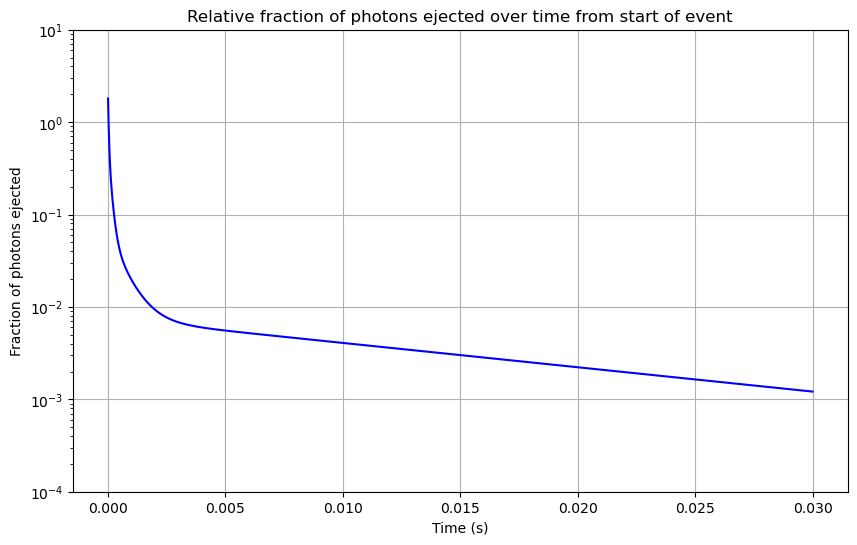

In [95]:
fig, ax = plt.subplots(figsize=(10,6))
ax.semilogy(t, np.abs(f_t), c='b')
ax.set_title("Relative fraction of photons ejected over time from start of event")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fraction of photons ejected")
ax.set_ylim(10e-5,10)
ax.grid()

In [98]:
def generate_coords(mu_x, mu_y, sigma2=0.00021233045007200478): 
    ''' This function will generate a set of coordinates for x and y, based on the centre of the event (input). It will only generate one at a time
    no need for custom functions here because numpy already has a sampler for gaussian distribution'''
    x_coord = random.gauss(mu_x, sigma2)
    y_coord = random.gauss(mu_y, sigma2)
    return x_coord, y_coord



Text(0.5, 0, 'X position from event source (m)')

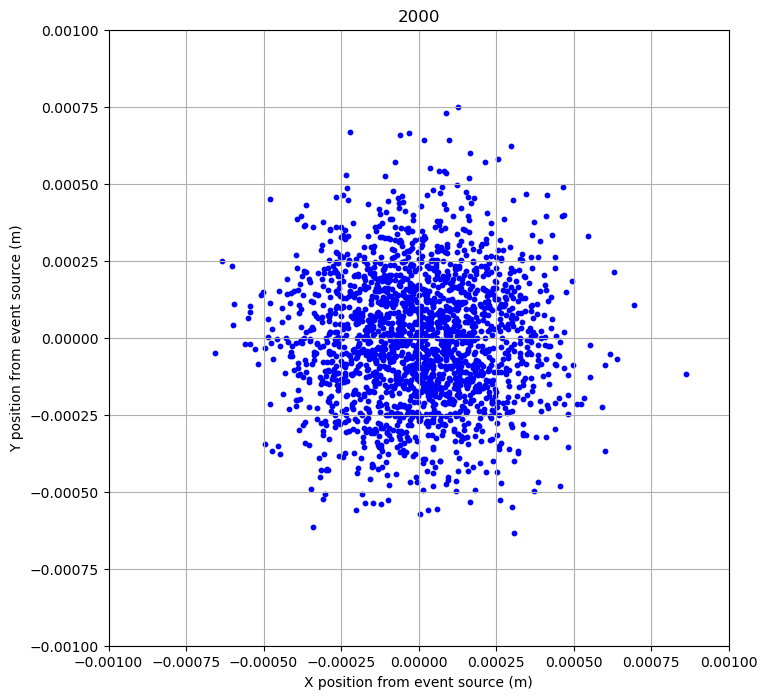

In [116]:
fig, ax = plt.subplots(figsize=(8,8))
x = [0]*2000
y = [0]*2000
for i in range(2000): 
    x[i], y[i] = generate_coords(0,0)

ax.scatter(x, y, c='b', s= 10)
ax.set_ylim(-0.001,0.001)
ax.set_xlim(-0.001,0.001)
ax.grid()
ax.set_title('2000')
ax.set_ylabel('Y position from event source (m)')
ax.set_xlabel('X position from event source (m)')


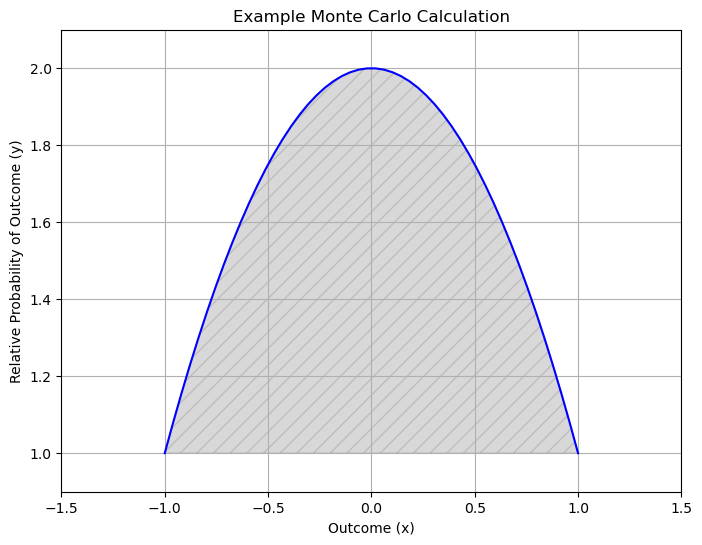

In [134]:
x = np.linspace(-1,1)
y = -(x)**2 + 2

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(x, y, c = 'b')
ax.set_title("Example Monte Carlo Calculation")
ax.set_xlabel("Outcome (x)")
ax.set_ylabel("Relative Probability of Outcome (y)")
ax.set_ylim(0.9,2.1)
ax.set_xlim(-1.5,1.5)
ax.grid()
ax.fill_between(x, y, 1, alpha=0.3, color='gray', where=(y >= 1), hatch='//')  # Shade the area


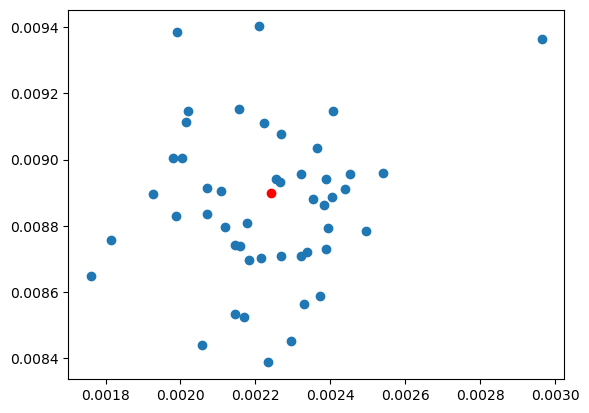

In [16]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# Path to your CSV file
csv_file_path = 'testfile.csv'
source_file_path = 'sources_testfile.csv'

# Lists to hold coordinates
x_coords = []
y_coords = []
z_coords = []

sx_coords = []
sy_coords = []
sz_coords = []

# Read flat list of coordinates from one row
with open(csv_file_path, newline='') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        flat_coords = [float(value) for value in row]
        # Group values into x, y, z
        for i in range(0, len(flat_coords), 3):
            x_coords.append(flat_coords[i])
            y_coords.append(flat_coords[i + 1])
            z_coords.append(flat_coords[i + 2])
        break  # only read the first row

# Read flat list of source coordinates from one row
columns = ['x[px]', 'y[px]', 't[s]']
sourceread = pd.read_csv(source_file_path)
sources = np.array(sourceread[columns])

# Plotting
plt.scatter(x_coords, y_coords)
plt.scatter(sources[:,0], sources[:,1], c='r')
plt.show()

In [ ]:
# first t is train, second t is test 
##          xyt             yt              xy
t100t100 = [0.0040,         0.0037,         0.0029]
t100t75 = [0.0057,          0.0058,         0.0040]
t100t50 = [0.0089,          0.0085,         0.0071]
t100t25 = [0.0241,          0.0258,         0.0204]

t75t100 = [0.0029,          0.0017,         0.0019]
t75t75 = [0.0042,           0.0030,         0.0025]
t75t50 = [0.0061,           0.0042,         0.0039]
t75t25 = [0.0168,           0.0154,         0.0123]

t50t100 = [0.0066,          0.0084,         0.0123]
t50t75 = [0.0072,           0.0091,         0.0070]
t50t50 = [0.0078,           0.0095,         0.0076]
t50t25 = [0.0127,           0.0158,         0.0117]

t25t100 = [0.0035,          0.0029,         0.0025]
t25t75 = [0.0036,           0.0030,         0.0026]
t25t50 = [0.0035,           0.0029,         0.0026]
t25t25 = [0.0048,           0.0041,         0.0042]

testing = [25, 50, 75, 100]
training = [25, 50, 75, 100]

### xyt, tested rows and trained columns
xyt = [[0.004, 0.0029, 0.0066, 0.0035],
 [0.0057, 0.0042, 0.0072, 0.0036],
 [0.0089, 0.0061, 0.0078, 0.0035],
 [0.0241, 0.0168, 0.0127, 0.0048]]
xyt = np.array(xyt)


### yt
yt = [[0.0037, 0.0017, 0.0084, 0.0029],
 [0.0058, 0.0030, 0.0091, 0.0030],
 [0.0085, 0.0042, 0.0095, 0.0029],
 [0.0258, 0.0154, 0.0158, 0.0041]]
yt = np.array(yt)

### xy
xy = [[0.0029, 0.0019, 0.0123, 0.0025], 
 [0.0040, 0.0025, 0.0070, 0.0026],
 [0.0071, 0.0039, 0.0076, 0.0026],
 [0.0204, 0.0123, 0.0117, 0.0042]]
xy = np.array(xy)

In [21]:
### xyt, trained rows and tested columns
T_xyt = xyt.T
T_yt = yt.T 
T_xy = xy.T 

Text(0.5, 0, 'Training Eventscale')

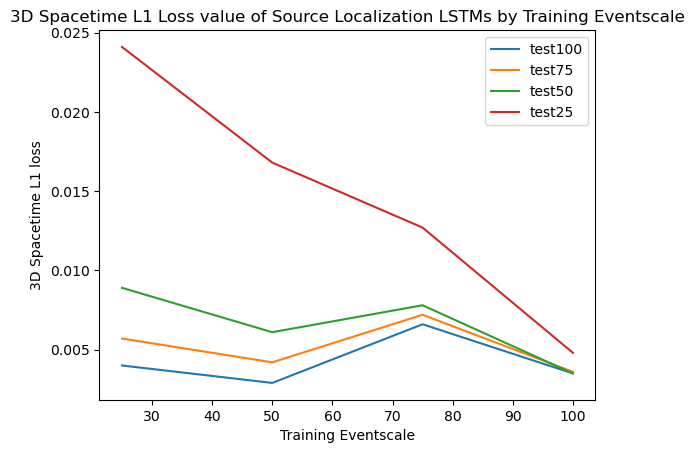

In [ ]:
plt.plot(training, xyt[0], label = 'test100')
plt.plot(training, xyt[1], label = 'test75')
plt.plot(training, xyt[2], label = 'test50')
plt.plot(training, xyt[3], label = 'test25')
plt.legend()
plt.title('3D Spacetime L1 Loss value of Source Localization LSTMs by Training Eventscale')
plt.ylabel('3D Spacetime L1 loss')
plt.xlabel('Training Eventscale')

Text(0.5, 0, 'Training Eventscale')

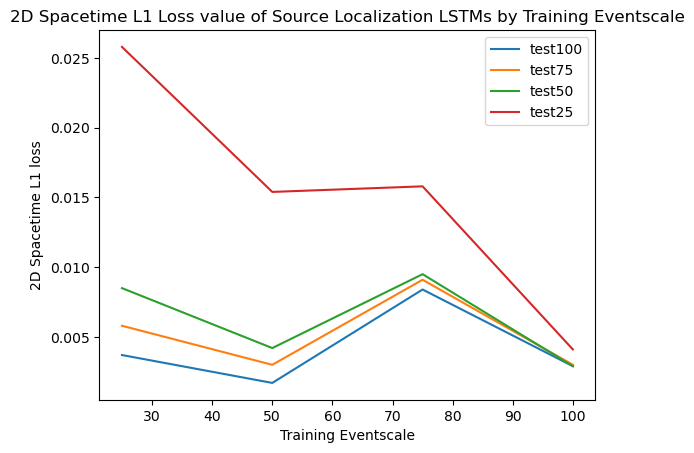

In [17]:
plt.plot(training, yt[0], label = 'test100')
plt.plot(training, yt[1], label = 'test75')
plt.plot(training, yt[2], label = 'test50')
plt.plot(training, yt[3], label = 'test25')
plt.legend()
plt.title('2D Spacetime L1 Loss value of Source Localization LSTMs by Training Eventscale')
plt.ylabel('2D Spacetime L1 loss')
plt.xlabel('Training Eventscale')

Text(0.5, 0, 'Training Eventscale')

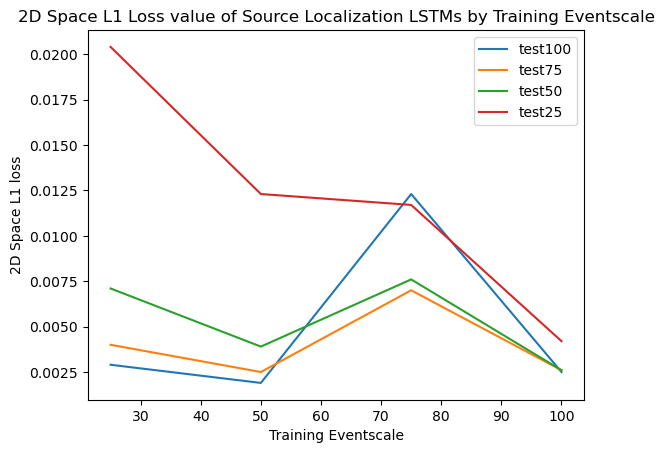

In [18]:
plt.plot(training, xy[0], label = 'test100')
plt.plot(training, xy[1], label = 'test75')
plt.plot(training, xy[2], label = 'test50')
plt.plot(training, xy[3], label = 'test25')
plt.legend()
plt.title('2D Space L1 Loss value of Source Localization LSTMs by Training Eventscale')
plt.ylabel('2D Space L1 loss')
plt.xlabel('Training Eventscale')

Text(0.5, 0, 'Testing Eventscale')

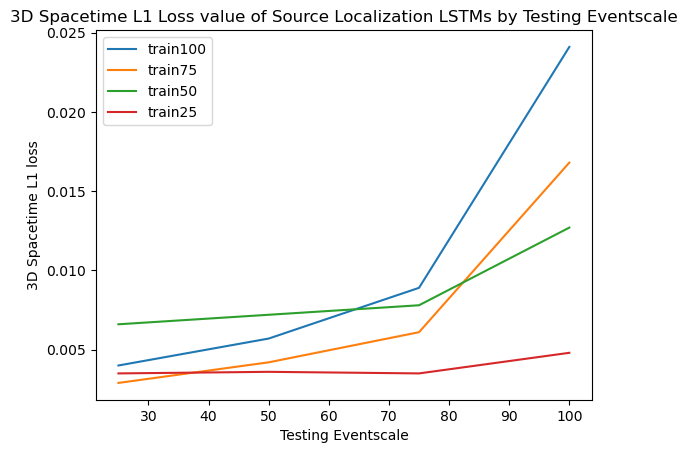

In [22]:
plt.plot(testing, T_xyt[0], label = 'train100')
plt.plot(testing, T_xyt[1], label = 'train75')
plt.plot(testing, T_xyt[2], label = 'train50')
plt.plot(testing, T_xyt[3], label = 'train25')
plt.legend()
plt.title('3D Spacetime L1 Loss value of Source Localization LSTMs by Testing Eventscale')
plt.ylabel('3D Spacetime L1 loss')
plt.xlabel('Testing Eventscale')

Text(0.5, 0, 'Testing Eventscale')

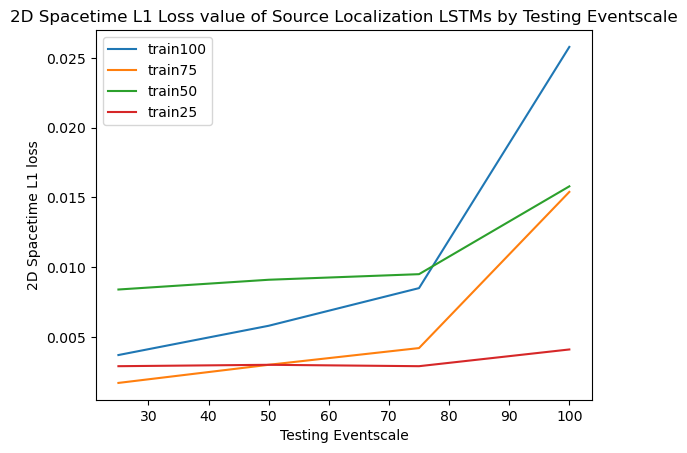

In [23]:
plt.plot(testing, T_yt[0], label = 'train100')
plt.plot(testing, T_yt[1], label = 'train75')
plt.plot(testing, T_yt[2], label = 'train50')
plt.plot(testing, T_yt[3], label = 'train25')
plt.legend()
plt.title('2D Spacetime L1 Loss value of Source Localization LSTMs by Testing Eventscale')
plt.ylabel('2D Spacetime L1 loss')
plt.xlabel('Testing Eventscale')

Text(0.5, 0, 'Testing Eventscale')

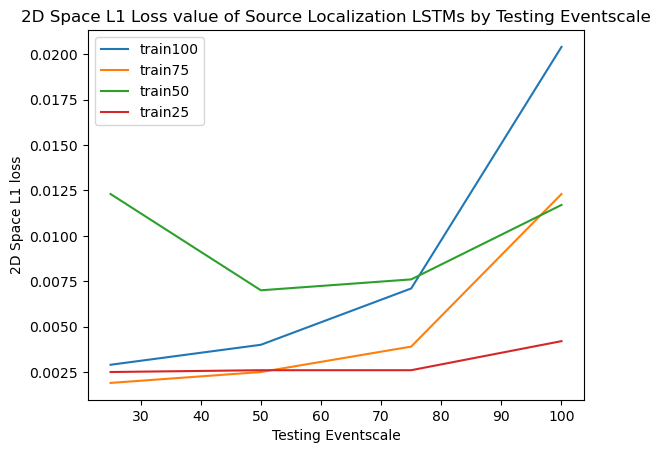

In [24]:
plt.plot(testing, T_xy[0], label = 'train100')
plt.plot(testing, T_xy[1], label = 'train75')
plt.plot(testing, T_xy[2], label = 'train50')
plt.plot(testing, T_xy[3], label = 'train25')
plt.legend()
plt.title('2D Space L1 Loss value of Source Localization LSTMs by Testing Eventscale')
plt.ylabel('2D Space L1 loss')
plt.xlabel('Testing Eventscale')

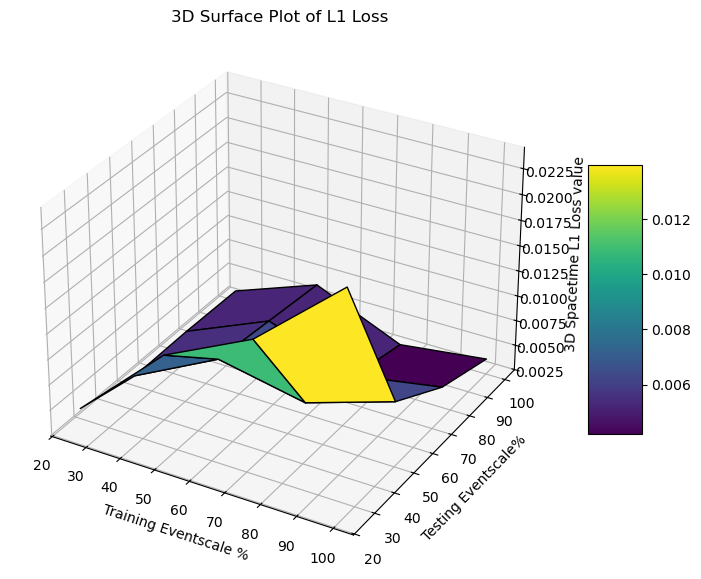

In [ ]:
## 3D Plot 

# Axes
train_percents = np.array([100, 75, 50, 25])
test_percents = np.array([100, 75, 50, 25])
Train, Test = np.meshgrid(train_percents, test_percents)

# Create the plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(Train, Test, xyt, cmap='viridis', edgecolor='k')

# Axis labels and title
ax.set_xlabel('Training Eventscale %')
ax.set_ylabel('Testing Eventscale%')
ax.set_zlabel('3D Spacetime L1 Loss value')
ax.set_title('3D Surface Plot of L1 Loss')

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Show plot
plt.show()

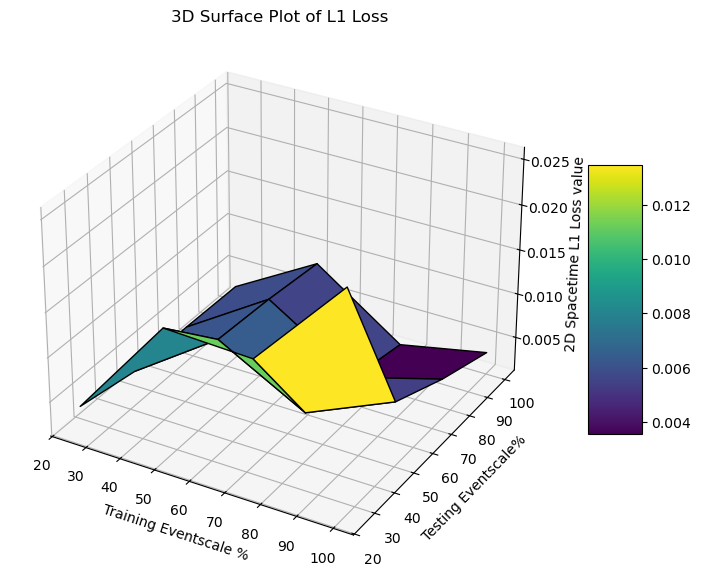

In [26]:
# Axes
train_percents = np.array([100, 75, 50, 25])
test_percents = np.array([100, 75, 50, 25])
Train, Test = np.meshgrid(train_percents, test_percents)

# Create the plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(Train, Test, yt, cmap='viridis', edgecolor='k')

# Axis labels and title
ax.set_xlabel('Training Eventscale %')
ax.set_ylabel('Testing Eventscale%')
ax.set_zlabel('2D Spacetime L1 Loss value')
ax.set_title('3D Surface Plot of L1 Loss')

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Show plot
plt.show()

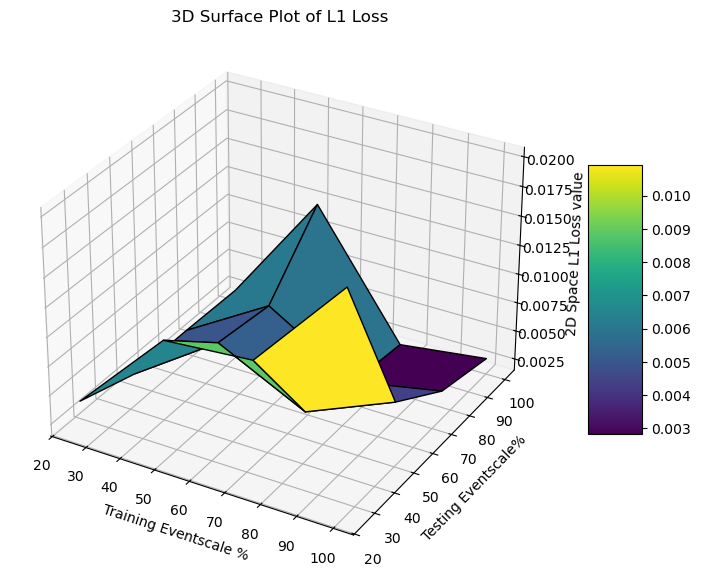

In [27]:
# Axes
train_percents = np.array([100, 75, 50, 25])
test_percents = np.array([100, 75, 50, 25])
Train, Test = np.meshgrid(train_percents, test_percents)

# Create the plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(Train, Test, xy, cmap='viridis', edgecolor='k')

# Axis labels and title
ax.set_xlabel('Training Eventscale %')
ax.set_ylabel('Testing Eventscale%')
ax.set_zlabel('2D Space L1 Loss value')
ax.set_title('3D Surface Plot of L1 Loss')

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Show plot
plt.show()

In [2]:
# 10%	0.0138	0.0133	0.0142
# 20%	0.0063	0.0049	0.0051
# 30%	0.0049	0.0033	0.0038
# 40%	0.0045	0.0029	0.0032
# 50%	0.0041	0.0023	0.0028
# 60%	0.0036	0.0019	0.0024
# 70%	0.0036	0.0018	0.0023
# 80%	0.0035	0.0018	0.0022
# 90%	0.0035	0.0018	0.0021
# 100%	0.0035	0.0018	0.0020

eventscales = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

## XYT Matrix
xyt = [0.0138,
0.0063,
0.0049,
0.0045,
0.0041,
0.0036,
0.0036,
0.0035,
0.0035,
0.0035]

## XY MATRIX   
xy = [0.0133,
0.0049,
0.0033,
0.0029,
0.0023,
0.0019,
0.0018,
0.0018,
0.0018,
0.0018]

## YT MATRIX 
yt = [0.0142,
0.0051,
0.0038,
0.0032,
0.0028,
0.0024,
0.0023,
0.0022,
0.0021,
0.0020]

Text(0.5, 0, 'Eventscale Value')

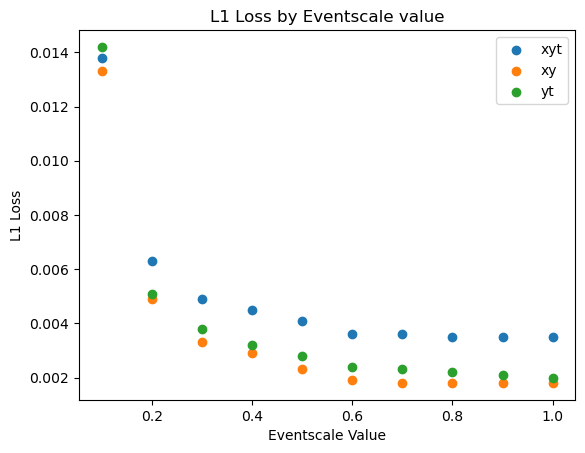

In [6]:
#### PLOTTING MIXED NETWORK TESTING 

plt.scatter(eventscales, xyt, label = 'xyt')
plt.scatter(eventscales, xy, label = 'xy')
plt.scatter(eventscales, yt, label = 'yt')

plt.legend()
plt.title("L1 Loss by Eventscale value")
plt.ylabel("L1 Loss")
plt.xlabel("Eventscale Value")

In [3]:
### Density tracker over time 

## ONE DIMENSIONAL (ONLY TIME)
def labelmaker(events=None, sp_density=None, t_density=None, noise=None, filename = None, folder = None): 
    '''creates labels based on my naming convention for different files, keeps it consistent and easy'''
    if folder: 
        folder = folder + '/'

    if filename: 
        datafile = str(filename) 
    else: 
        datafile = str(events) + 'ev_' + str(sp_density) + 'spd_' + str(t_density) + 'td_n' + str(noise)
    

    labelfile = 'labels_' + datafile + '.csv'
    sourcefile = 'sources_' + datafile + '.csv'
    ai_labelfile = datafile + '_results' + '.csv'
    centroidfile = datafile + '_centroids' + '.csv'
    datafile = datafile + '.csv'

    if folder: 
        datafile = folder + datafile 
        centroidfile = folder + centroidfile 
        ai_labelfile = folder + ai_labelfile 
        labelfile = folder + labelfile 
        sourcefile = folder + sourcefile 

    
    return datafile, labelfile, sourcefile

def datapull(events=None, sp_density=None, t_density=None, noise=None, filename = None, folder = None): 
    '''Returns data tensors for the given filenames'''
    datafile, labelfile, sourcefile = labelmaker(events, sp_density, t_density, noise, filename, folder)

    data = []
    with open(datafile, 'r') as f:
        for line in f:
            values = [float(v) for v in line.strip().split(',') if v.strip()]  # Convert to float

            if len(values) % 3 != 0:
                print(f"Warning: Skipping malformed row with {len(values)} values (not a multiple of 3)")
                continue  # Skip malformed rows
            
            coords = torch.tensor(values).reshape(-1, 3)  # Convert to (N, 3) tensor
            data.append(coords)  # Store as a tensor

    labelread = pd.read_csv(labelfile)
    labels = np.array(labelread['labels'])
    labels = torch.tensor(labels)

    columns = ['x[px]', 'y[px]', 't[s]']
    sourceread = pd.read_csv(sourcefile)
    sources = np.array(sourceread[columns])
    sources = torch.tensor(sources)

    return data, labels, sources


In [58]:
# Calculating bandwidth, sigma is the one given from the gaussian functions above 

data, labels, sources = datapull(filename = '1000ev_n0_es100')
time1 = data[1][:,0].numpy()

s = 0.00021233045007200478

s1 = statistics.stdev(time1)
n1 = len(time1)
h1 = 1.06*s*n1**(-1/5)

time2 = data[1][:,1].numpy()
s2 = statistics.stdev(time2)
n2 = len(time2)
h2 = 1.06*s*n2**(-1/5)

time3 = data[1][:,2].numpy()
s3 = statistics.stdev(time3)
n3 = len(time3)
h3 = 1.06*s3*n3**(-1/5)

h = np.array([h1, h2, h3])
h

array([0.00010062, 0.00010062, 0.00541343])

In [115]:
# reformatting the data for readability 
refitted = np.array([[0,0,0]])
for event in data[:10]: 
    event = event.numpy()
    refitted = np.concatenate((refitted, event))

refitted = np.delete(refitted, 0, axis = 0)
refitted

array([[0.85434926, 0.48860842, 0.54162425],
       [0.8544029 , 0.48852447, 0.53648877],
       [0.85455102, 0.48842263, 0.53643513],
       ...,
       [0.09495801, 0.73093116, 0.61604249],
       [0.09496473, 0.73111254, 0.63898259],
       [0.09510261, 0.73103386, 0.61599487]])

In [ ]:
# kernel definition

kde = KernelDensity(kernel='gaussian', bandwidth = h2).fit(refitted[:,:1])
log_density = kde.score_samples(refitted[:,:1])

# log density here is the values obtained from a pass of the y fitted kernel on all y coordinates


In [ ]:
source_array = sources[:10].numpy() # reduce it down to 10 events to not saturate the plot 
source_array.shape

exes = [1]*10

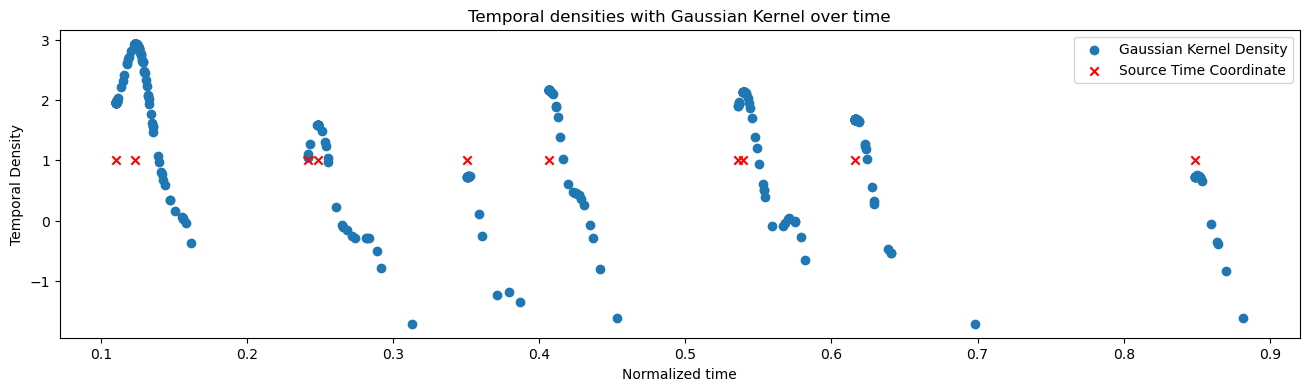

In [ ]:
### try it with time only 
times = refitted[:,2]
sorted_times = np.sort(times)
sorted_times
times = sorted_times.reshape(-1,1)
kde2 = KernelDensity(kernel='gaussian', bandwidth = h3).fit(times) # new kernel based on time coordinates only 
time_densities = kde2.score_samples(times)
x = np.linspace(times[0], times[-1], 407)
plt.figure(figsize=(16,4))
plt.scatter(times, time_densities, label = 'Gaussian Kernel Density')
plt.scatter(source_array[:,2], exes, c = 'red', marker = 'x', label = 'Source Time Coordinate')
plt.title("Temporal densities with Gaussian Kernel over time")
plt.xlabel("Normalized time")
plt.ylabel("Temporal Density")
plt.legend()


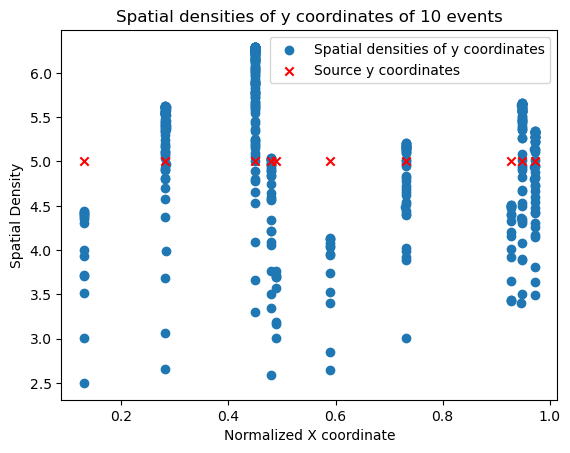

In [167]:
Xs = [5]*10
plt.scatter(refitted[:,1], log_density, label = 'Spatial densities of y coordinates')
plt.scatter(source_array[:,1], Xs, c = 'red', marker = 'x', label = 'Source y coordinates')
plt.title("Spatial densities of y coordinates of 10 events")
plt.xlabel("Normalized X coordinate")
plt.ylabel("Spatial Density")
plt.legend()